# 2D wave propagation in a wooden speaker cabinet

This notebook simulates acoustic wave propagation in a **2D rectangular wooden cabinet** with an **air-filled interior**. A point source is placed at the center of the cabinet, and the computational domain is larger than the cabinet so waves can radiate into the surrounding air.

Two **ports** on the left and right walls let the signal exit the cabinet. Two **microphones** outside the cabinet record the radiated pressure on each side.

Two materials are used:

| Material | Speed of sound | Density |
|----------|----------------|---------|
| Air      | 343 m/s        | 1.2 kg/m³ |
| Wood     | 3500 m/s       | 700 kg/m³ |

The cabinet is modeled as a hollow rectangular shell with uniform wall thickness.

This notebook solves the **2D Cartesian** wave equation (\(\partial_{xx} + \partial_{yy}\)) on a rectilinear grid. It is the correct model for a **rectangular** cabinet. The companion `wood_cabinet_3d.ipynb` revolves this cross-section into a cylinder for **geometry**, but the 3D physics require the full Cartesian Laplacian in \((x, y, z)\) — not a 2D \((r, x)\) axisymmetric reduction.

## Setup

In [1]:
import numpy as np
from jax import jit
from jax import numpy as jnp
from jaxdf import FourierSeries
from matplotlib import pyplot as plt

from jwave.acoustics import TimeWavePropagationSettings, simulate_wave_propagation
from jwave.geometry import Domain, Medium, Sources, TimeAxis
from jwave.signal_processing import apply_ramp, tone_burst
from jwave.utils import show_field, show_positive_field

## Geometry

The cabinet is `20 mm × 50 mm` at `0.5 mm` resolution (`CABINET_SIZE = (40, 100)` grid points). The domain is `(120, 300)`, i.e. three times the cabinet height and width. The cabinet is centered in the domain, leaving a margin of surrounding air.

Two **ports** are cut in the left and right walls so sound can exit the cabinet. **Microphones** are placed outside the cabinet on both sides, aligned with the port centers.

In [2]:
# Acoustic material properties
C_AIR, RHO_AIR = 343.0, 1.2
C_WOOD, RHO_WOOD = 3500.0, 700.0

# Cabinet geometry (0.5 mm resolution, same physical size as the 3D notebook)
DX = (0.5e-3, 0.5e-3)
CABINET_SIZE = (40, 100)  # 20 mm height × 50 mm width
DOMAIN_SIZE = (3 * CABINET_SIZE[0], 3 * CABINET_SIZE[1])
WALL_THICKNESS = 6  # 3 mm wood walls
PORT_HEIGHT = 10  # 5 mm port opening
MIC_OFFSET = 40  # 20 mm outside the cabinet walls

domain = Domain(DOMAIN_SIZE, DX)
ny, nx = domain.N
cab_h, cab_w = CABINET_SIZE

# Center the cabinet in the domain
y0, x0 = (ny - cab_h) // 2, (nx - cab_w) // 2
y1, x1 = y0 + cab_h, x0 + cab_w

# Vertical port opening centered on the left/right walls
port_y0 = (y0 + y1 - PORT_HEIGHT) // 2
port_y1 = port_y0 + PORT_HEIGHT

# Microphone positions outside the cabinet, aligned with the ports
mic_y = (y0 + y1) // 2
left_mic_x = x0 - MIC_OFFSET - 20
right_mic_x = x1 + MIC_OFFSET - 1 + 20


SPATIAL_STRIDE = 2  # store every 2nd grid point (4× less field memory)
SNAPSHOT_STRIDE = 200  # plot every Nth stored frame (full t_end still covered)


def make_recording_sensor(
    mic_y: int,
    left_mic_x: int,
    right_mic_x: int,
    ny: int,
    nx: int,
    spatial_stride: int,
):
    """Record microphones + spatially downsampled pressure at every time step."""
    coarse_ny = (ny + spatial_stride - 1) // spatial_stride
    coarse_nx = (nx + spatial_stride - 1) // spatial_stride
    field_size = coarse_ny * coarse_nx

    def sensor(p, u, rho):
        grid = p.on_grid[..., 0]
        mics = jnp.array([grid[mic_y, left_mic_x], grid[mic_y, right_mic_x]])
        coarse = grid[::spatial_stride, ::spatial_stride]
        return jnp.concatenate([mics, coarse.ravel()])

    def unpack(recordings):
        mics = recordings[:, :2]
        fields = recordings[:, 2 : 2 + field_size].reshape(-1, coarse_ny, coarse_nx)
        return mics, fields

    return sensor, unpack, coarse_ny, coarse_nx


print(f"Domain size: {domain.N}, dx: {domain.dx}")
print(f"Cabinet bounds: y=[{y0}, {y1}), x=[{x0}, {x1})")
print(f"Ports: y=[{port_y0}, {port_y1}) on left/right walls")
print(f"Microphones at (y, x) = ({mic_y}, {left_mic_x}) and ({mic_y}, {right_mic_x})")

Domain size: (120, 300), dx: (0.0005, 0.0005)
Cabinet bounds: y=[40, 80), x=[100, 200)
Ports: y=[55, 65) on left/right walls
Microphones at (y, x) = (60, 40) and (60, 259)


## Heterogeneous medium (air + wood)

The domain is initialized with air. Wood is assigned to the cabinet walls, leaving an air cavity inside. The left and right walls are then opened over the port height so the signal can radiate outside.

In [3]:
sound_speed = np.full(domain.N, C_AIR, dtype=np.float64)
density = np.full(domain.N, RHO_AIR, dtype=np.float64)

# Top and bottom walls
sound_speed[y0 : y0 + WALL_THICKNESS, x0:x1] = C_WOOD
sound_speed[y1 - WALL_THICKNESS : y1, x0:x1] = C_WOOD
density[y0 : y0 + WALL_THICKNESS, x0:x1] = RHO_WOOD
density[y1 - WALL_THICKNESS : y1, x0:x1] = RHO_WOOD

# Left and right walls
sound_speed[y0:y1, x0 : x0 + WALL_THICKNESS] = C_WOOD
sound_speed[y0:y1, x1 - WALL_THICKNESS : x1] = C_WOOD
density[y0:y1, x0 : x0 + WALL_THICKNESS] = RHO_WOOD
density[y0:y1, x1 - WALL_THICKNESS : x1] = RHO_WOOD

# Open the left and right ports
sound_speed[port_y0:port_y1, x0 : x0 + WALL_THICKNESS] = C_AIR
sound_speed[port_y0:port_y1, x1 - WALL_THICKNESS : x1] = C_AIR
density[port_y0:port_y1, x0 : x0 + WALL_THICKNESS] = RHO_AIR
density[port_y0:port_y1, x1 - WALL_THICKNESS : x1] = RHO_AIR

sound_speed_field = FourierSeries(np.expand_dims(sound_speed, -1), domain)
density_field = FourierSeries(np.expand_dims(density, -1), domain)

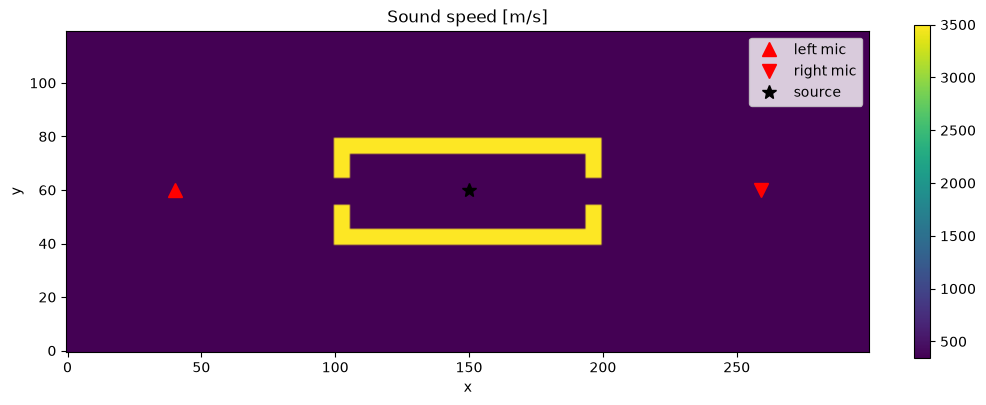

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(sound_speed, origin="lower", cmap="viridis")
ax.set_title("Sound speed [m/s]")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax, fraction=0.046)

# Mark microphones
ax.plot(left_mic_x, mic_y, "r^", markersize=10, label="left mic")
ax.plot(right_mic_x, mic_y, "rv", markersize=10, label="right mic")
ax.plot(nx // 2, ny // 2, "k*", markersize=10, label="source")
ax.legend(loc="upper right")

plt.tight_layout()

In [5]:
medium = Medium(
    domain=domain,
    sound_speed=sound_speed_field,
    density=density_field,
    pml_size=10,
)
# A slightly smaller CFL keeps the ported cabinet stable
time_axis = TimeAxis.from_medium(medium, cfl=0.2, t_end=6e-3)
# Progress uses jax.debug.callback (safe with os.write, not tqdm).
# First @jit call also compiles XLA — you may see a one-off "constant folding" warning.
settings = TimeWavePropagationSettings(show_progress=True, progress_interval_pct=1.0)
print(time_axis)

## Point source at cabinet center

Because the cabinet is centered in the domain, its geometric center coincides with the domain center. We drive the source with a 2 kHz tone burst.

Text(0, 0.5, 'amplitude')

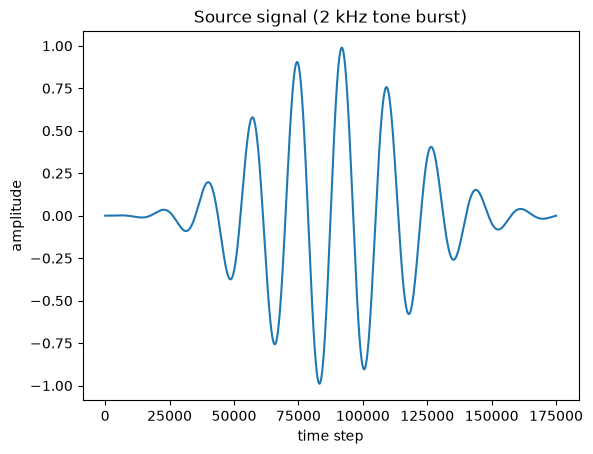

In [6]:
sample_freq = 1.0 / time_axis.dt
source_signal = apply_ramp(
    tone_burst(sample_freq, 2000.0, 10),
    time_axis.dt,
    2000.0,
)

source_y, source_x = ny // 2, nx // 2

sources = Sources(
    positions=((source_y,), (source_x,)),
    signals=jnp.expand_dims(source_signal, 0),
    dt=time_axis.dt,
    domain=domain,
)

recording_sensor, unpack_recordings, coarse_ny, coarse_nx = make_recording_sensor(
    mic_y,
    left_mic_x,
    right_mic_x,
    ny,
    nx,
    SPATIAL_STRIDE,
)
mic_y_coarse = mic_y // SPATIAL_STRIDE
left_mic_x_coarse = left_mic_x // SPATIAL_STRIDE
right_mic_x_coarse = right_mic_x // SPATIAL_STRIDE

plt.plot(source_signal)
plt.title("Source signal (2 kHz tone burst)")
plt.xlabel("time step")
plt.ylabel("amplitude")

## Simulation

One run over the **full** `t_end` records:

1. Both **microphone traces** at every time step
2. A **spatially downsampled** pressure field (`SPATIAL_STRIDE`) at every time step

Memory scales as `Nt × (Ny/SPATIAL_STRIDE) × (Nx/SPATIAL_STRIDE)`, not the full grid. For snapshots below, subsample in time with `SNAPSHOT_STRIDE` — the interval `[0, t_end]` is still fully simulated.

In [ ]:
import time

@jit
def run_simulation(sources):
    return simulate_wave_propagation(
        medium,
        time_axis,
        sources=sources,
        sensors=recording_sensor,
        settings=settings,
    )


t0 = time.perf_counter()
recordings = run_simulation(sources)
print(f"Simulation finished in {time.perf_counter() - t0:.1f} s")

mic_recordings, pressure_coarse = unpack_recordings(recordings)
left_pressure = mic_recordings[:, 0]
right_pressure = mic_recordings[:, 1]
n_frames = int(time_axis.Nt) // SNAPSHOT_STRIDE + 1
print(
    f"Coarse field stored: {pressure_coarse.shape} "
    f"({pressure_coarse.nbytes / 1e6:.0f} MB); ~{n_frames} snapshot frames"
)

Wave propagation: step 6301/210000 (3%) | ETA 2m 23s                                            

## Microphone comparison

Pressure time series recorded outside the left and right ports. Because the setup is symmetric, the two microphones should see very similar signals, with small differences caused by numerical discretization and boundary effects.

Peak |p| left mic:  0.019901
Peak |p| right mic: 0.019897
Relative difference: 0.02%


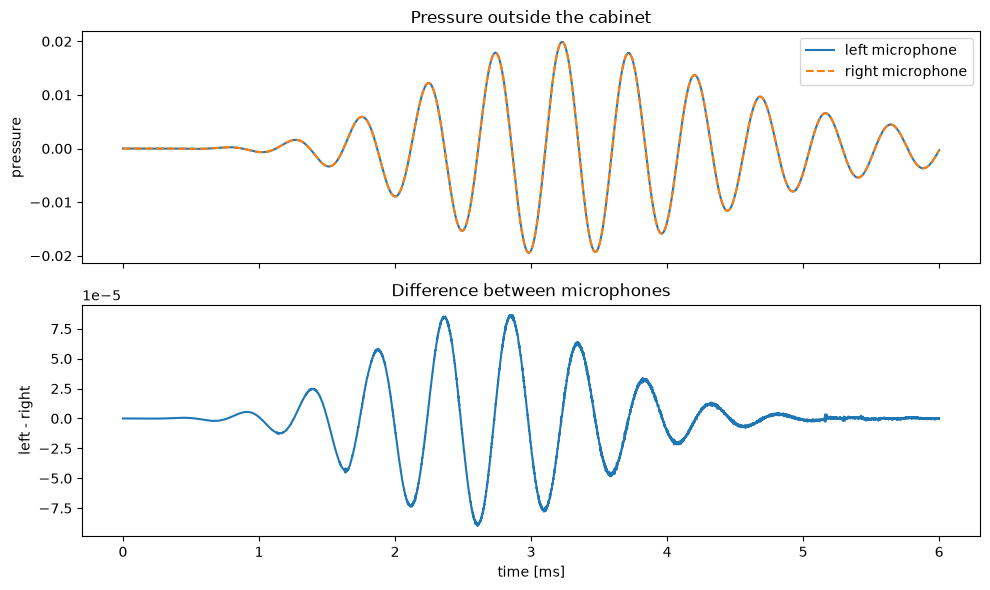

In [ ]:
time = time_axis.to_array()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(time * 1e3, left_pressure, label="left microphone")
axes[0].plot(time * 1e3, right_pressure, label="right microphone", linestyle="--")
axes[0].set_ylabel("pressure")
axes[0].set_title("Pressure outside the cabinet")
axes[0].legend()

axes[1].plot(time * 1e3, left_pressure - right_pressure)
axes[1].set_xlabel("time [ms]")
axes[1].set_ylabel("left - right")
axes[1].set_title("Difference between microphones")

plt.tight_layout()

peak_left = jnp.max(jnp.abs(left_pressure))
peak_right = jnp.max(jnp.abs(right_pressure))
print(f"Peak |p| left mic:  {peak_left:.6f}")
print(f"Peak |p| right mic: {peak_right:.6f}")
print(f"Relative difference: {100 * jnp.abs(peak_left - peak_right) / jnp.maximum(peak_left, peak_right):.2f}%")

## Field snapshots

Plot evenly spaced frames from the **same** simulation (full `t_end`). Only every `SNAPSHOT_STRIDE`-th stored time step is drawn, but those frames span the whole interval.

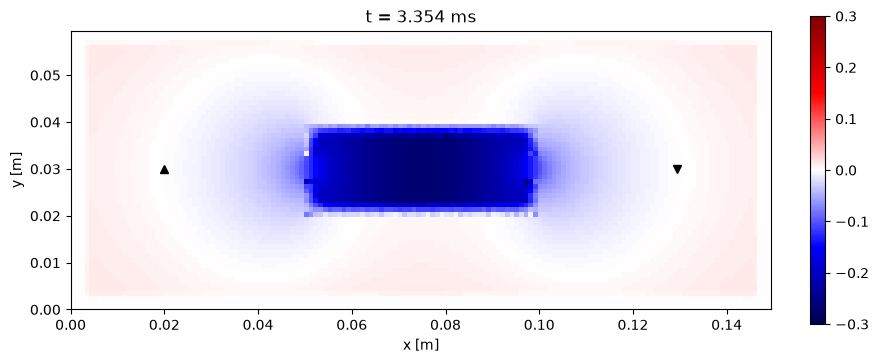

In [ ]:
from IPython.display import clear_output as clc

snapshot_frames = pressure_coarse[::SNAPSHOT_STRIDE]
snapshot_times = time_axis.to_array()[::SNAPSHOT_STRIDE]
print(f"Animating {snapshot_frames.shape[0]} frames over t ∈ [0, {time_axis.t_end * 1e3:.2f}] ms")

extent = (
    0,
    (nx - 1) * DX[1],
    0,
    (ny - 1) * DX[0],
)

for field, t in zip(snapshot_frames, snapshot_times):
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(
        field,
        origin="lower",
        extent=extent,
        aspect="equal",
        cmap="seismic",
        vmin=-0.3,
        vmax=0.3,
    )
    ax.plot(left_mic_x * DX[1], mic_y * DX[0], "k^", markersize=6)
    ax.plot(right_mic_x * DX[1], mic_y * DX[0], "kv", markersize=6)
    ax.set_title(f"t = {t * 1e3:.3f} ms")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.show()
    clc(wait=True)
    plt.close()